# FMD Terminal Extrapolation Experiment

Evaluate the branch experiment that extends tblastn mat_peptide boundaries when HSP query coordinates show small missing N/C-terminal amino acids.

Run this notebook on branch `experiment/fmd-terminal-extrapolation-v2`. Outputs go to `terminal_extrapolation_outputs/`.

## What This Compares

- **Baseline**: existing strict-clean FMD outputs generated before terminal extrapolation.
- **Experiment**: reruns FMD strict-clean tblastn using the current branch code.

Main questions:

- Did exact/coordinate accuracy improve?
- Did boundary-offset tool cases decrease?
- Did any exact matches regress?

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'inputs').exists() and (BASE_DIR / 'tiers' / TIER / 'inputs').exists():
    BASE_DIR = BASE_DIR / 'tiers' / TIER

INPUT_DIR = BASE_DIR / 'inputs'
BASELINE_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR = BASE_DIR / 'terminal_extrapolation_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})


## Baseline Snapshot

This reads the previous strict-clean FMD results. It does not rerun BLAST.

In [2]:
baseline_vs_truth = pd.read_csv(BASELINE_DIR / 'tblastn_vs_truth.tsv', sep='	')
baseline_fmd_df = baseline_vs_truth[baseline_vs_truth['virus'] == 'FMD'].copy()
baseline_fmd_df.head()

,virus,record_id,method,ref_name,pred_name,source_name,pred_start,pred_end,strand,status,...,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
855,FMD,AY687333.1,tblastn,Lpro,Lpro,NaN,1082.0,1684.0,+,ok,...,Lpro,1082.0,1684.0,Lpro,1.0000,1.0000,True,True,True,Correct
856,FMD,AY687333.1,tblastn,VP4,VP4,NaN,1685.0,1939.0,+,ok,...,VP4,1685.0,1939.0,VP4,1.0000,1.0000,True,True,True,Correct
857,FMD,AY687333.1,tblastn,VP2,VP2,NaN,1940.0,2593.0,+,ok,...,VP2,1940.0,2593.0,VP2,1.0000,1.0000,True,True,True,Correct
858,FMD,AY687333.1,tblastn,VP3,VP3,NaN,2594.0,3250.0,+,ok,...,VP3,2594.0,3250.0,VP3,1.0000,1.0000,True,True,True,Correct
859,FMD,AY687333.1,tblastn,VP1,VP1,NaN,3251.0,3880.0,+,ok,...,VP1,3251.0,3886.0,VP1,0.9906,0.9906,True,True,False,Boundary offset


## Run Experiment On FMD Strict-Clean

This reruns only FMD. It will call tblastn, so this is the slow cell.

In [3]:
experiment_df, experiment_summary = run_tblastn_against_truth(
    virus_label='FMD',
    ref_path=DATA / 'FMD_ref_test.gb',
    query_path=INPUT_DIR / 'FMD_records.gb',
    output_dir=OUTPUT_DIR / 'fmd',
    progress=True,
)

experiment_df.to_csv(OUTPUT_DIR / 'fmd_tblastn_vs_truth.tsv', sep='	', index=False)
experiment_summary.to_csv(OUTPUT_DIR / 'fmd_tblastn_summary.tsv', sep='	', index=False)
experiment_summary

tblastn  FMD:   0%|          | 0/96 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,FMD,tblastn,1152,1114,1130,0.9944,96.7,98.09


## Raw Accuracy Comparison

In [4]:
def raw_fmd_summary(df, label):
    total = len(df)
    exact = int(df['exact_match'].sum())
    coord = int(df['coord_correct'].sum())
    return {
        'run': label,
        'total': total,
        'exact_match': exact,
        'coord_correct': coord,
        'coord_only': coord - exact,
        'failed_coord_or_name': total - coord,
        'exact_pct': round(exact / total * 100, 2),
        'coord_pct': round(coord / total * 100, 2),
        'failed_pct': round((total - coord) / total * 100, 2),
    }

raw_compare = pd.DataFrame([
    raw_fmd_summary(baseline_fmd_df, 'baseline'),
    raw_fmd_summary(experiment_df, 'terminal_extrapolation'),
])
raw_compare.to_csv(OUTPUT_DIR / 'fmd_raw_accuracy_comparison.tsv', sep='	', index=False)
raw_compare

,run,total,exact_match,coord_correct,coord_only,failed_coord_or_name,exact_pct,coord_pct,failed_pct
0,baseline,1152,1088,1131,43,21,94.44,98.18,1.82
1,terminal_extrapolation,1152,1114,1130,16,22,96.70,98.09,1.91


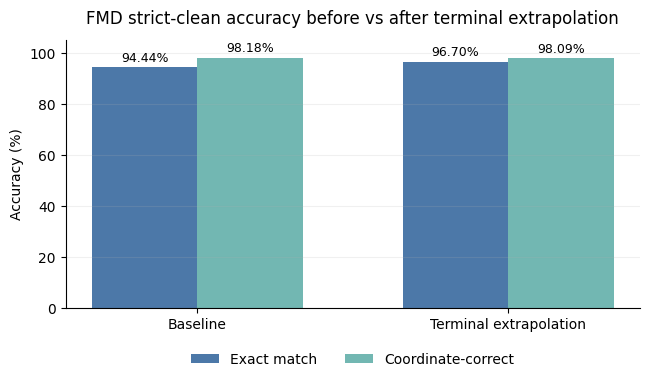

In [5]:
plot_df = raw_compare.copy()
plot_df['label'] = plot_df['run'].map({
    'baseline': 'Baseline',
    'terminal_extrapolation': 'Terminal extrapolation',
}).fillna(plot_df['run'])
plot_df = plot_df.set_index('label').loc[['Baseline', 'Terminal extrapolation']].reset_index()

fig, ax = plt.subplots(figsize=(6.6, 4.2))
x = range(len(plot_df))
width = 0.34
bars1 = ax.bar([v - width / 2 for v in x], plot_df['exact_pct'], width, label='Exact match', color='#4C78A8')
bars2 = ax.bar([v + width / 2 for v in x], plot_df['coord_pct'], width, label='Coordinate-correct', color='#72B7B2')

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(list(x), plot_df['label'])
ax.set_title('FMD strict-clean accuracy before vs after terminal extrapolation', pad=12)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.18)

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUTPUT_DIR / 'fmd_accuracy_comparison.png', bbox_inches='tight', dpi=160)
plt.show()

## Ref-Aware Failure Adjudication

Reuses the FMD final adjudication logic from the strict-clean notebook so causes are comparable before/after.

In [6]:
fmd_bundle = load_reference_bundle(DATA / 'FMD_ref_test.gb')
fmd_ref_model = pd.DataFrame([
    {
        'ref_name': feature['name'],
        'ref_start': feature['start'],
        'ref_end': feature['end'],
        'ref_len': feature['end'] - feature['start'] + 1,
    }
    for feature in fmd_bundle['features']
])


def prepare_fmd_failures(df):
    failures = df[~df['exact_match']].copy()
    if failures.empty:
        return failures
    if 'ref_name' not in failures.columns:
        failures['ref_name'] = failures['pred_name']
    failures['delta_start'] = failures['pred_start'] - failures['truth_start']
    failures['delta_end'] = failures['pred_end'] - failures['truth_end']
    failures['pred_len'] = failures['pred_end'] - failures['pred_start'] + 1
    failures['truth_len'] = failures['truth_end'] - failures['truth_start'] + 1
    failures = failures.merge(fmd_ref_model, on='ref_name', how='left')
    failures['pred_minus_ref_len'] = failures['pred_len'] - failures['ref_len']
    failures['truth_minus_ref_len'] = failures['truth_len'] - failures['ref_len']
    failures['pred_minus_truth_len'] = failures['pred_len'] - failures['truth_len']
    return failures


def final_reason(row):
    feature = row['ref_name']
    mode = row.get('failure_mode')
    ds = row.get('delta_start')
    de = row.get('delta_end')
    pred_ref = row.get('pred_minus_ref_len')
    truth_ref = row.get('truth_minus_ref_len')

    if pd.isna(row.get('truth_name')):
        return pd.Series({'final_blame': 'ref_truth', 'final_cause': 'truth_feature_absent'})
    if pred_ref == 0 and truth_ref != 0:
        return pd.Series({'final_blame': 'ref_truth', 'final_cause': 'ref_query_boundary_convention_mismatch'})
    if mode == 'Not lifted':
        return pd.Series({'final_blame': 'tool', 'final_cause': 'no_hit'})
    if feature == '3A' and ds == 0 and de == -111:
        return pd.Series({'final_blame': 'tool', 'final_cause': 'major_c_terminal_truncation'})
    if feature in {'Lpro', '3Cpro'} and ds == 12 and de == 0:
        return pd.Series({'final_blame': 'tool', 'final_cause': 'n_terminal_truncation_12bp'})
    if feature == '2A' and mode == 'Boundary offset':
        return pd.Series({'final_blame': 'tool', 'final_cause': 'short_peptide_boundary_offset'})
    if feature == '3B' and de == -3:
        return pd.Series({'final_blame': 'tool', 'final_cause': 'minor_c_terminal_truncation_3bp'})
    if feature == 'VP1':
        return pd.Series({'final_blame': 'tool', 'final_cause': 'minor_vp1_boundary_offset'})
    return pd.Series({'final_blame': 'tool', 'final_cause': 'boundary_offset_matches_neither_ref_nor_truth'})


def adjudicate(df, label):
    failures = prepare_fmd_failures(df)
    if failures.empty:
        return failures, pd.DataFrame(), pd.DataFrame()
    final_cols = failures.apply(final_reason, axis=1)
    final = pd.concat([failures, final_cols], axis=1)
    final['run'] = label
    blame = final.groupby(['run', 'final_blame']).size().reset_index(name='cases')
    cause = final.groupby(['run', 'final_blame', 'final_cause']).size().reset_index(name='cases')
    return final, blame, cause

baseline_final_cases, baseline_blame_compare, baseline_cause_compare = adjudicate(baseline_fmd_df, 'baseline')
experiment_final_cases, experiment_blame_compare, experiment_cause_compare = adjudicate(experiment_df, 'terminal_extrapolation')

final_cases = pd.concat([baseline_final_cases, experiment_final_cases], ignore_index=True)
blame_compare = pd.concat([baseline_blame_compare, experiment_blame_compare], ignore_index=True)
cause_compare = pd.concat([baseline_cause_compare, experiment_cause_compare], ignore_index=True)

final_cases.to_csv(OUTPUT_DIR / 'fmd_final_cases_comparison.tsv', sep='	', index=False)
blame_compare.to_csv(OUTPUT_DIR / 'fmd_final_blame_comparison.tsv', sep='	', index=False)
cause_compare.to_csv(OUTPUT_DIR / 'fmd_final_cause_comparison.tsv', sep='	', index=False)

cause_compare

,run,final_blame,final_cause,cases
0,baseline,ref_truth,ref_query_boundary_convention_mismatch,25
1,baseline,ref_truth,truth_feature_absent,3
2,baseline,tool,boundary_offset_matches_neither_ref_nor_truth,1
3,baseline,tool,major_c_terminal_truncation,1
4,baseline,tool,minor_c_terminal_truncation_3bp,1
5,baseline,tool,minor_vp1_boundary_offset,8
6,baseline,tool,n_terminal_truncation_12bp,15
7,baseline,tool,no_hit,1
8,baseline,tool,short_peptide_boundary_offset,9
9,terminal_extrapolation,ref_truth,ref_query_boundary_convention_mismatch,26


In [7]:
pivot = cause_compare.pivot_table(
    index=['final_blame', 'final_cause'],
    columns='run',
    values='cases',
    fill_value=0,
).reset_index()
if 'baseline' in pivot.columns and 'terminal_extrapolation' in pivot.columns:
    pivot['delta'] = pivot['terminal_extrapolation'] - pivot['baseline']
pivot.to_csv(OUTPUT_DIR / 'fmd_final_cause_delta.tsv', sep='	', index=False)
pivot

run,final_blame,final_cause,baseline,terminal_extrapolation,delta
0,ref_truth,ref_query_boundary_convention_mismatch,25.0,26.0,1.0
1,ref_truth,truth_feature_absent,3.0,3.0,0.0
2,tool,boundary_offset_matches_neither_ref_nor_truth,1.0,0.0,-1.0
3,tool,major_c_terminal_truncation,1.0,1.0,0.0
4,tool,minor_c_terminal_truncation_3bp,1.0,0.0,-1.0
5,tool,minor_vp1_boundary_offset,8.0,7.0,-1.0
6,tool,n_terminal_truncation_12bp,15.0,0.0,-15.0
7,tool,no_hit,1.0,1.0,0.0
8,tool,short_peptide_boundary_offset,9.0,0.0,-9.0


## Cases Fixed Or Regressed

A fixed case was non-exact in baseline but exact after terminal extrapolation. A regressed case was exact in baseline but non-exact after terminal extrapolation.

In [8]:
key_cols = ['record_id', 'pred_name']
base_status = baseline_fmd_df[key_cols + ['exact_match', 'coord_correct', 'pred_start', 'pred_end', 'truth_start', 'truth_end', 'failure_mode']].copy()
base_status = base_status.rename(columns={c: f'baseline_{c}' for c in base_status.columns if c not in key_cols})
exp_status = experiment_df[key_cols + ['exact_match', 'coord_correct', 'pred_start', 'pred_end', 'truth_start', 'truth_end', 'failure_mode', 'status']].copy()
exp_status = exp_status.rename(columns={c: f'experiment_{c}' for c in exp_status.columns if c not in key_cols})
case_compare = base_status.merge(exp_status, on=key_cols, how='outer')

fixed = case_compare[(case_compare['baseline_exact_match'] == False) & (case_compare['experiment_exact_match'] == True)].copy()
regressed = case_compare[(case_compare['baseline_exact_match'] == True) & (case_compare['experiment_exact_match'] == False)].copy()

fixed.to_csv(OUTPUT_DIR / 'fmd_fixed_cases.tsv', sep='	', index=False)
regressed.to_csv(OUTPUT_DIR / 'fmd_regressed_cases.tsv', sep='	', index=False)

print('fixed cases:', len(fixed))
print('regressed cases:', len(regressed))
display(fixed.head(30))
display(regressed.head(30))

fixed cases: 26
regressed cases: 0


,record_id,pred_name,baseline_exact_match,baseline_coord_correct,baseline_pred_start,baseline_pred_end,baseline_truth_start,baseline_truth_end,baseline_failure_mode,experiment_exact_match,experiment_coord_correct,experiment_pred_start,experiment_pred_end,experiment_truth_start,experiment_truth_end,experiment_failure_mode,experiment_status
24,DQ533483.2,2A,False,True,3893.0,3943.0,3890.0,3943.0,Boundary offset,True,True,3890.0,3943.0,3890.0,3943.0,Correct,ok_extrapolated
48,DQ989304.1,2A,False,True,3934.0,3984.0,3931.0,3984.0,Boundary offset,True,True,3931.0,3984.0,3931.0,3984.0,Correct,ok_extrapolated
156,DQ989313.1,2A,False,True,3980.0,4030.0,3977.0,4030.0,Boundary offset,True,True,3977.0,4030.0,3977.0,4030.0,Correct,ok_extrapolated
211,DQ989317.1,Lpro,False,True,1194.0,1784.0,1182.0,1784.0,Boundary offset,True,True,1182.0,1784.0,1182.0,1784.0,Correct,ok_extrapolated
223,DQ989318.1,Lpro,False,True,1190.0,1780.0,1178.0,1780.0,Boundary offset,True,True,1178.0,1780.0,1178.0,1780.0,Correct,ok_extrapolated
384,GU931682.1,2A,False,True,3892.0,3942.0,3889.0,3942.0,Boundary offset,True,True,3889.0,3942.0,3889.0,3942.0,Correct,ok_extrapolated
403,KJ754939.1,Lpro,False,True,1113.0,1703.0,1101.0,1703.0,Boundary offset,True,True,1101.0,1703.0,1101.0,1703.0,Correct,ok_extrapolated
440,MF372126.1,VP1,False,True,3355.0,3978.0,3352.0,3978.0,Boundary offset,True,True,3352.0,3978.0,3352.0,3978.0,Correct,ok_extrapolated
451,MG372727.1,Lpro,False,True,1051.0,1632.0,1051.0,1647.0,Boundary offset,True,True,1051.0,1647.0,1051.0,1647.0,Correct,ok_extrapolated
535,MK088171.1,Lpro,False,True,1114.0,1704.0,1102.0,1704.0,Boundary offset,True,True,1102.0,1704.0,1102.0,1704.0,Correct,ok_extrapolated


,record_id,pred_name,baseline_exact_match,baseline_coord_correct,baseline_pred_start,baseline_pred_end,baseline_truth_start,baseline_truth_end,baseline_failure_mode,experiment_exact_match,experiment_coord_correct,experiment_pred_start,experiment_pred_end,experiment_truth_start,experiment_truth_end,experiment_failure_mode,experiment_status
